📂 Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 Found Zip at: /content/drive/MyDrive/FYP Project/final_dataset.zip
📂 Unzipping to: /content/drive/MyDrive/FYP Project/final_dataset_custom (This takes a moment)...
✅ Unzip complete!
✅ Found dataset at: /content/drive/MyDrive/FYP Project/final_dataset_custom

📦 Loading Images...
Found 16937 images belonging to 10 classes.
Found 1350 images belonging to 10 classes.

🧠 Building ResNet50 Brain...

🔥 STARTING TRAINING (T4 GPU)...
Epoch 1/20
530/530 ━━━━━━━━━━━━━━━━━━━━ 0s 636ms/step - accuracy: 0.7389 - loss: 0.8071
Epoch 1: val_accuracy improved from -inf to 0.97630, saving model to /content/drive/MyDrive/FYP Project/best_fish_resnet50_2.keras
530/530 ━━━━━━━━━━━━━━━━━━━━ 370s 672ms/step - accuracy: 0.7392 - loss: 0.8063 - val_accuracy: 0.9763 - val_loss: 0.0910
Epoch 2/20
530/530 ━━━━━━━━━━━━━━━━━━━━ 0s 606ms/step - accuracy: 0.9646 

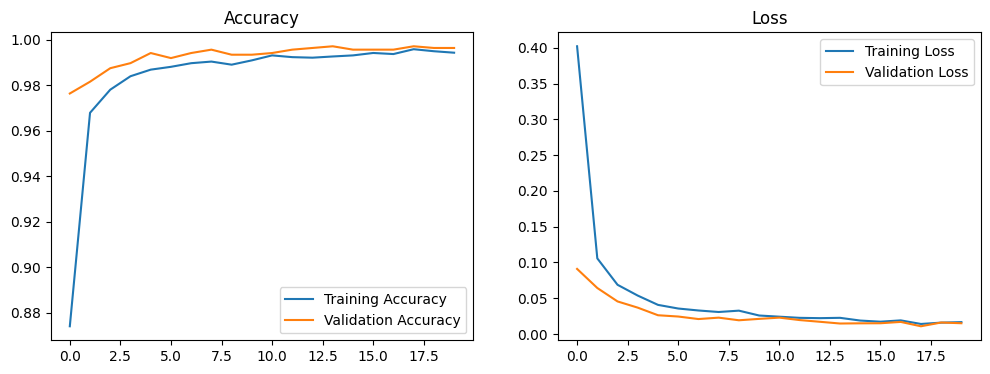


🎉 DONE! The file 'best_fish_resnet50_2.keras' is now in the Files sidebar.
👉 Right-click it and select 'Download' to save it to your laptop.


In [ ]:
import os
import zipfile
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt
from google.colab import drive

# ================= 1. SETUP & MOUNT DRIVE =================
print("📂 Mounting Google Drive...")
drive.mount('/content/drive')

# CONFIGURATION
# Your specific path from the error message
ZIP_FILE_PATH = "/content/drive/MyDrive/FYP Project/final_dataset.zip"
EXTRACT_PATH = "/content/drive/MyDrive/FYP Project/final_dataset_custom" # We unzip to local Colab storage for speed

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 0.0001
# ==========================================================

def run_full_training():
    # --- STEP 2: UNZIP DATASET ---
    if not os.path.exists(EXTRACT_PATH):
        print(f"🚀 Found Zip at: {ZIP_FILE_PATH}")
        print(f"📂 Unzipping to: {EXTRACT_PATH} (This takes a moment)...")
        try:
            with zipfile.ZipFile(ZIP_FILE_PATH, 'r') as zip_ref:
                zip_ref.extractall(EXTRACT_PATH)
            print("✅ Unzip complete!")
        except FileNotFoundError:
            print(f"❌ ERROR: Cannot find the file: {ZIP_FILE_PATH}")
            print("   Please check if 'final_dataset.zip' is exactly in that folder in your Drive.")
            return
    else:
        print("ℹ️ Dataset already unzipped locally.")

    # --- STEP 3: FIND THE TRAIN FOLDER ---
    # Logic: Sometimes zip files create double folders. We find where 'train' actually is.
    dataset_root = None

    # Check Option A: /content/temp_dataset/final_dataset_split/train
    option_a = os.path.join(EXTRACT_PATH, "final_dataset")
    # Check Option B: /content/temp_dataset/train (if you zipped the inside files directly)
    option_b = EXTRACT_PATH

    if os.path.exists(os.path.join(option_a, 'train')):
        dataset_root = option_a
        print(f"✅ Found dataset at: {dataset_root}")
    elif os.path.exists(os.path.join(option_b, 'train')):
        dataset_root = option_b
        print(f"✅ Found dataset at: {dataset_root}")
    else:
        print("❌ ERROR: Could not find 'train' folder!")
        print(f"   Listing contents of {EXTRACT_PATH}:")
        print(os.listdir(EXTRACT_PATH))
        return

    # --- STEP 4: PREPARE DATA ---
    print("\n📦 Loading Images...")

    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=20,
        horizontal_flip=True,
        width_shift_range=0.1,
        height_shift_range=0.1
    )

    val_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input
    )

    train_generator = train_datagen.flow_from_directory(
        os.path.join(dataset_root, 'train'),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical'
    )

    val_generator = val_datagen.flow_from_directory(
        os.path.join(dataset_root, 'val'),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical'
    )

    # --- STEP 5: BUILD MODEL (ResNet50) ---
    print("\n🧠 Building ResNet50 Brain...")
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.3)(x)
    x = Dense(256, activation='relu')(x)
    predictions = Dense(train_generator.num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)

    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    # --- STEP 6: TRAIN ---
    # Save directly to Google Drive
    # Make sure your Drive is mounted first!
    SAVE_PATH = "/content/drive/MyDrive/FYP Project/best_fish_resnet50_2.keras"

    checkpoint = ModelCheckpoint(SAVE_PATH,
                                monitor='val_accuracy',
                                save_best_only=True,
                                mode='max',
                                verbose=1)

    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    print("\n🔥 STARTING TRAINING (T4 GPU)...")
    history = model.fit(
        train_generator,
        epochs=EPOCHS,
        validation_data=val_generator,
        callbacks=[checkpoint, early_stop]
    )

    # --- STEP 7: SAVE RESULTS ---
    plot_history(history)
    print("\n🎉 DONE! The file 'best_fish_resnet50_2.keras' is now in the Files sidebar.")
    print("👉 Right-click it and select 'Download' to save it to your laptop.")

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Loss')
    plt.legend()

    plt.savefig("training_results.png")
    plt.show()

# Run Everything
if __name__ == "__main__":
    run_full_training()

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam
from google.colab import drive
import os

# ==========================================
# 1. CONNECT TO GOOGLE DRIVE
# ==========================================
print("Mounting Google Drive...")
drive.mount('/content/drive')

# ==========================================
# 2. SETUP PATHS (UPDATE THIS PART!)
# ==========================================
# In Colab, your Drive is at /content/drive/MyDrive/
# Update these lines to match where you uploaded your folder
BASE_PATH = '/content/drive/MyDrive/FYP Project/final_dataset_custom'

TRAIN_DIR = os.path.join(BASE_PATH, 'train')
VAL_DIR = os.path.join(BASE_PATH, 'val')
# Note: If your model is also in Drive, update this path too:
MODEL_PATH = '/content/drive/MyDrive/FYP Project/resnet50_2.keras'

# Verify paths exist
if not os.path.exists(TRAIN_DIR):
    print(f"ERROR: Could not find train folder at {TRAIN_DIR}")
    print("Please check your Google Drive folder structure.")
else:
    print(f"Found training data at: {TRAIN_DIR}")

BATCH_SIZE = 32
IMG_SIZE = (224, 224)

# ==========================================
# 3. LOAD DATA GENERATORS
# ==========================================
print("Setting up Data Generators...")
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical'
)

# ==========================================
# 4. LOAD MODEL & UNFREEZE LAYERS
# ==========================================
print(f"Loading model from {MODEL_PATH}...")
model = load_model(MODEL_PATH)

print("Unfreezing top layers for fine-tuning...")
model.trainable = True

# Freeze the bottom layers (Stage 1-4)
# Fine-tune only the very top (Stage 5 + Head)
FINE_TUNE_AT = 140

for layer in model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

print(f"Layers training: {len(model.layers) - FINE_TUNE_AT}")

# ==========================================
# 5. RE-COMPILE & TRAIN
# ==========================================
print("Compiling with Low Learning Rate (1e-5)...")
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Starting Fine-Tuning...")
FINE_TUNE_EPOCHS = 15

history_fine = model.fit(
    train_generator,
    epochs=FINE_TUNE_EPOCHS,
    validation_data=val_generator,
    verbose=1
)

# ==========================================
# 6. SAVE TO DRIVE
# ==========================================
# Save directly to Drive so you don't lose it if Colab disconnects
SAVE_PATH = '/content/drive/MyDrive/FYP Project/resnet50_2_finetuned.keras'
model.save(SAVE_PATH)
print(f"Fine-tuning complete. Model saved to Google Drive at: {SAVE_PATH}")

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found training data at: /content/drive/MyDrive/FYP Project/final_dataset_custom/train
Setting up Data Generators...
Found 16937 images belonging to 10 classes.
Found 1350 images belonging to 10 classes.
Loading model from /content/drive/MyDrive/FYP Project/resnet50_2.keras...
Unfreezing top layers for fine-tuning...
Layers training: 39
Compiling with Low Learning Rate (1e-5)...
Starting Fine-Tuning...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
530/530 ━━━━━━━━━━━━━━━━━━━━ 4695s 9s/step - accuracy: 0.9913 - loss: 0.0257 - val_accuracy: 0.9956 - val_loss: 0.0132
Epoch 2/15
530/530 ━━━━━━━━━━━━━━━━━━━━ 2263s 4s/step - accuracy: 0.9941 - loss: 0.0199 - val_accuracy: 0.9956 - val_loss: 0.0132
Epoch 3/15
530/530 ━━━━━━━━━━━━━━━━━━━━ 2260s 4s/step - accuracy: 0.9933 - loss: 0.0215 - val_accuracy: 0.9963 - val_loss: 0.0127
Epoch 4/15
530/530 ━━━━━━━━━━━━━━━━━━━━ 2289s 4s/step - accuracy: 0.9938 - loss: 0.0193 - val_accuracy: 0.9963 - val_loss: 0.0134
Epoch 5/15
530/530 ━━━━━━━━━━━━━━━━━━━━ 2242s 4s/step - accuracy: 0.9929 - loss: 0.0204 - val_accuracy: 0.9963 - val_loss: 0.0133
Epoch 6/15
530/530 ━━━━━━━━━━━━━━━━━━━━ 2265s 4s/step - accuracy: 0.9914 - loss: 0.0232 - val_accuracy: 0.9963 - val_loss: 0.0130
Epoch 7/15
530/530 ━━━━━━━━━━━━━━━━━━━━ 2287s 4s/step - accuracy: 0.9931 - loss: 0.0192 - val_accuracy: 0.9963 - val_loss: 0.0124
Epoch 8/15
530/530 ━━━━━━━━━━━━━━━━━━━━ 2272s 4s/step - accuracy: 0.9933 - loss: 0.0199 - 

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import os
from google.colab import drive

# 1. Mount Drive again (since you disconnected)
drive.mount('/content/drive')

# 2. Setup Data Paths (Point to where your data is)
# Update this if you are using the unzipped local folder or Drive folder
# For speed, let's assume you point to Drive for this one-time check
VAL_DIR = '/content/drive/MyDrive/FYP Project/final_dataset_custom/val'

# 3. Setup Generator
val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False  # CRITICAL: Must be false for reports
)

# 4. Load the BEST model you saved
# Make sure this matches the name you used in the checkpoint code
BEST_MODEL_PATH = '/content/drive/MyDrive/resnet50_2_finetuned.keras'

print(f"Loading model from {BEST_MODEL_PATH}...")
if os.path.exists(BEST_MODEL_PATH):
    model = load_model(BEST_MODEL_PATH)
    print("Model loaded successfully!")
else:
    print("ERROR: Could not find the model file. Check the filename in your Drive!")

# 5. Run Prediction
if 'model' in locals():
    print("Evaluating model... (This may take a few minutes directly from Drive)")
    Y_pred = model.predict(val_generator, verbose=1)
    y_pred = np.argmax(Y_pred, axis=1)

    # 6. Generate Report
    class_names = list(val_generator.class_indices.keys())
    print("\n" + "="*50)
    print("FINAL FINE-TUNED REPORT")
    print("="*50)
    print(classification_report(val_generator.classes, y_pred, target_names=class_names))

NameError: name 'history_fine' is not defined

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import os
from google.colab import drive

# 1. Mount Drive again (since you disconnected)
drive.mount('/content/drive')

# 2. Setup Data Paths (Point to where your data is)
# Update this if you are using the unzipped local folder or Drive folder
# For speed, let's assume you point to Drive for this one-time check
VAL_DIR = '/content/drive/MyDrive/FYP Project/final_dataset_custom/val'

# 3. Setup Generator
val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False  # CRITICAL: Must be false for reports
)

# 4. Load the BEST model you saved
# Make sure this matches the name you used in the checkpoint code
BEST_MODEL_PATH = '/content/drive/MyDrive/FYP Project/resnet50_2_finetuned.keras'

print(f"Loading model from {BEST_MODEL_PATH}...")
if os.path.exists(BEST_MODEL_PATH):
    model = load_model(BEST_MODEL_PATH)
    print("Model loaded successfully!")
else:
    print("ERROR: Could not find the model file. Check the filename in your Drive!")

# 5. Run Prediction
if 'model' in locals():
    print("Evaluating model... (This may take a few minutes directly from Drive)")
    Y_pred = model.predict(val_generator, verbose=1)
    y_pred = np.argmax(Y_pred, axis=1)

    # 6. Generate Report
    class_names = list(val_generator.class_indices.keys())
    print("\n" + "="*50)
    print("FINAL FINE-TUNED REPORT")
    print("="*50)
    print(classification_report(val_generator.classes, y_pred, target_names=class_names))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 1350 images belonging to 10 classes.
Loading model from /content/drive/MyDrive/FYP Project/resnet50_2_finetuned.keras...
Model loaded successfully!
Evaluating model... (This may take a few minutes directly from Drive)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


43/43 ━━━━━━━━━━━━━━━━━━━━ 436s 10s/step

FINAL FINE-TUNED REPORT
                      precision    recall  f1-score   support

           AngelFish       1.00      0.99      0.99        78
         Common Carp       1.00      1.00      1.00        51
            GoldFish       0.99      0.99      0.99       153
             Gourami       0.99      1.00      1.00       176
          Molly_fish       1.00      1.00      1.00        80
           PlatyFish       0.99      0.99      0.99       135
                Rohu       1.00      1.00      1.00        51
           ZebraFish       1.00      1.00      1.00       232
cardinal_tetra_final       1.00      1.00      1.00        10
          guppy_fish       1.00      1.00      1.00       384

            accuracy                           1.00      1350
           macro avg       1.00      1.00      1.00      1350
        weighted avg       1.00      1.00      1.00      1350



In [ ]:
# resnet training = resnet_3
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from google.colab import drive
import os
import zipfile

# ==========================================
# 1. SETUP & UNZIP (High Speed)
# ==========================================
drive.mount('/content/drive')

# PATH CONFIGURATION
ZIP_PATH = '/content/drive/MyDrive/FYP Project/dataset_3.zip' # <--- Make sure this matches your file!
EXTRACT_PATH = '/content/drive/MyDrive/FYP Project/dataset_3'          # Extract to Colab local disk (Fast)

if not os.path.exists(EXTRACT_PATH):
    print("🚀 Unzipping dataset... (This makes training 10x faster)")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)
    print("✅ Extraction complete!")
else:
    print("Dataset already extracted.")

# Define directory paths inside the unzipped folder
# Adjust 'final_dataset_split' if your zip structure is different
TRAIN_DIR = os.path.join(EXTRACT_PATH, 'train')
VAL_DIR = os.path.join(EXTRACT_PATH, 'val')

# ==========================================
# 2. DATA GENERATORS
# ==========================================
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

print("Setting up data generators...")

# Augmentation for Training
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input,
    horizontal_flip=True,      # Safe to keep (flipping a flipped fish is still valid)
    width_shift_range=0.1,     # Very slight movement is okay
    height_shift_range=0.1     # Very slight movement is okay
    #rotation_range=20,
    #width_shift_range=0.2,
    #height_shift_range=0.2,
    #shear_range=0.1,
    #zoom_range=0.2,
    #horizontal_flip=True,
    #fill_mode='nearest'
)

# No augmentation for Validation
val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical'
)

# Detect number of classes automatically
NUM_CLASSES = len(train_generator.class_indices)
print(f"✅ Detected {NUM_CLASSES} classes (Should be 22 now including Neon Tetra)")

# ==========================================
# 3. BUILD NEW MODEL (ResNet V3)
# ==========================================
print("Building Fresh ResNet50 Model...")

# Load Base (ImageNet weights, no top)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Create new "Head" for your 22 classes
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x) # Helps prevent overfitting
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# FREEZE the base first (Standard Transfer Learning rule)
# We only train the new head for the first few epochs
for layer in base_model.layers:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# ==========================================
# 4. PHASE 1: WARM UP (Train Head Only)
# ==========================================
print("\n--- PHASE 1: WARM UP (Training new layers only) ---")
# This is quick, just to get the new 'Neon Tetra' neuron ready
history_warmup = model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator
)

# ==========================================
# 5. PHASE 2: FINE TUNING (The Real Training)
# ==========================================
print("\n--- PHASE 2: FINE TUNING (Unfreezing base) ---")

# Unfreeze the top layers of ResNet to learn specific features (scales/stripes)
base_model.trainable = True

# Fine-tune from layer 140 onwards (Stage 5)
FINE_TUNE_AT = 140
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

# Recompile with LOW learning rate (Crucial!)
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Callbacks to save the best version
checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/resnet50_3.keras', # New Name!
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

# Train longer this time
history_fine = model.fit(
    train_generator,
    epochs=20, # Give it time to learn the Neon vs Cardinal difference
    validation_data=val_generator,
    callbacks=[checkpoint, early_stop]
)

print("Training Complete! Best model saved as 'resnet50_3.keras'")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset already extracted.
Setting up data generators...
Found 18004 images belonging to 11 classes.
Found 1364 images belonging to 11 classes.
✅ Detected 11 classes (Should be 22 now including Neon Tetra)
Building Fresh ResNet50 Model...

--- PHASE 1: WARM UP (Training new layers only) ---
Epoch 1/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 373s 639ms/step - accuracy: 0.7555 - loss: 0.8044 - val_accuracy: 0.9670 - val_loss: 0.1034
Epoch 2/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 335s 596ms/step - accuracy: 0.9475 - loss: 0.1513 - val_accuracy: 0.9780 - val_loss: 0.0678
Epoch 3/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 328s 583ms/step - accuracy: 0.9630 - loss: 0.1082 - val_accuracy: 0.9846 - val_loss: 0.0618
Epoch 4/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 332s 589ms/step - accuracy: 0.9615 - loss: 0.1038 - val_accuracy: 0.9802 - val_loss: 0.0549
Epoch 5/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 331s 587ms/step 

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import os
from google.colab import drive

# 1. Mount Drive again (since you disconnected)
drive.mount('/content/drive')

# 2. Setup Data Paths (Point to where your data is)
# Update this if you are using the unzipped local folder or Drive folder
# For speed, let's assume you point to Drive for this one-time check
VAL_DIR = '/content/drive/MyDrive/FYP Project/dataset_5/val'

# 3. Setup Generator
val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False  # CRITICAL: Must be false for reports
)

# 4. Load the BEST model you saved
# Make sure this matches the name you used in the checkpoint code
BEST_MODEL_PATH = '/content/drive/MyDrive/FYP Project/resnet50_5.keras'

print(f"Loading model from {BEST_MODEL_PATH}...")
if os.path.exists(BEST_MODEL_PATH):
    model = load_model(BEST_MODEL_PATH)
    print("Model loaded successfully!")
else:
    print("ERROR: Could not find the model file. Check the filename in your Drive!")

# 5. Run Prediction
if 'model' in locals():
    print("Evaluating model... (This may take a few minutes directly from Drive)")
    Y_pred = model.predict(val_generator, verbose=1)
    y_pred = np.argmax(Y_pred, axis=1)

    # 6. Generate Report
    class_names = list(val_generator.class_indices.keys())
    print("\n" + "="*50)
    print("FINAL FINE-TUNED REPORT")
    print("="*50)
    print(classification_report(val_generator.classes, y_pred, target_names=class_names))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 1688 images belonging to 12 classes.
Loading model from /content/drive/MyDrive/FYP Project/resnet50_5.keras...
Model loaded successfully!
Evaluating model... (This may take a few minutes directly from Drive)
53/53 ━━━━━━━━━━━━━━━━━━━━ 518s 10s/step

FINAL FINE-TUNED REPORT
                precision    recall  f1-score   support

     AngelFish       0.98      0.96      0.97        52
Cardinal_tetra       0.94      0.65      0.77        23
   Cherry_barb       1.00      1.00      1.00       307
   Common Carp       0.98      1.00      0.99        51
      GoldFish       0.95      0.97      0.96       153
       Gourami       0.99      1.00      0.99       176
    Guppy_fish       1.00      0.99      0.99       404
    Molly_fish       1.00      1.00      1.00        80
    Neon_tetra       0.80      1.00      0.89        24
     PlatyFish       0.98     

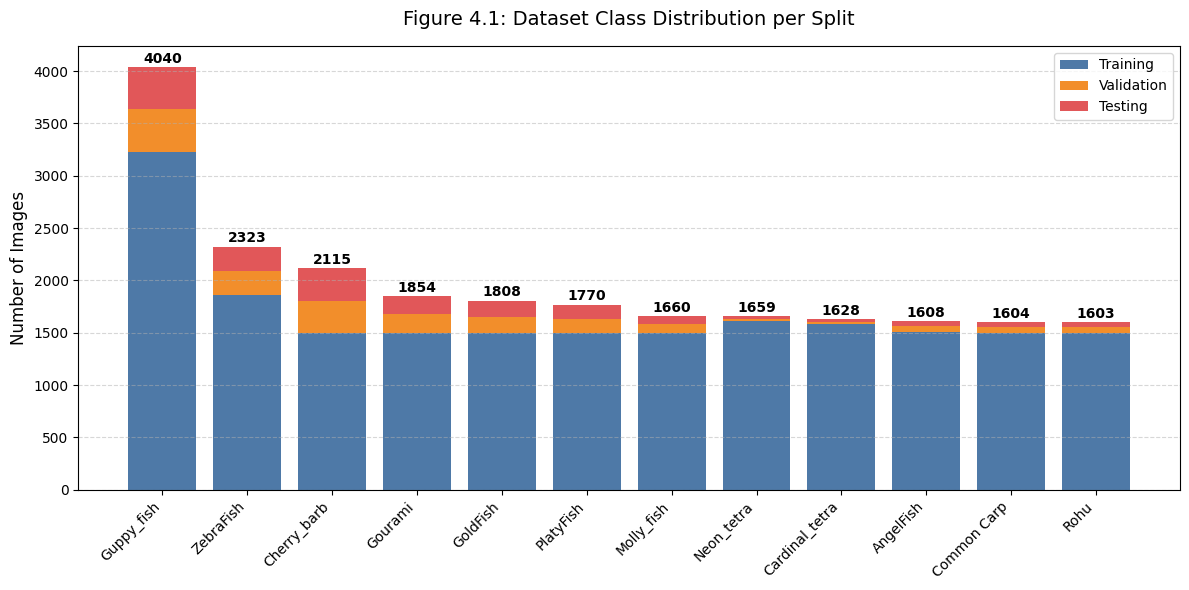

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# 1. Update this to the EXACT path where 'dataset_5' sits in your Colab sidebar
# If you mounted drive, it usually looks like: '/content/drive/MyDrive/FYP Project/dataset_5'
dataset_path = '/content/drive/MyDrive/FYP Project/dataset_5'

def count_images_in_split(split_name):
    path = os.path.join(dataset_path, split_name)
    counts = {}

    if not os.path.exists(path):
        print(f"Warning: Path {path} not found. Check if the folder name is correct!")
        return counts

    for species in os.listdir(path):
        species_path = os.path.join(path, species)
        if os.path.isdir(species_path):
            # This counts files while ignoring hidden system files like .ipynb_checkpoints
            num_files = len([f for f in os.listdir(species_path)
                             if os.path.isfile(os.path.join(species_path, f))
                             and not f.startswith('.')])
            counts[species] = num_files
    return counts

# 2. Use the exact folder names from your screenshot
train_counts = count_images_in_split('train')
val_counts = count_images_in_split('val')
test_counts = count_images_in_split('test')

# 3. Align the data
all_species = sorted(list(set(train_counts.keys()) | set(val_counts.keys()) | set(test_counts.keys())))

if not all_species:
    print("Error: No species folders found. Please double-check your 'dataset_path'.")
else:
    df = pd.DataFrame({
        'Common Name': all_species,
        'Training': [train_counts.get(s, 0) for s in all_species],
        'Validation': [val_counts.get(s, 0) for s in all_species],
        'Testing': [test_counts.get(s, 0) for s in all_species]
    })

    df['Total'] = df['Training'] + df['Validation'] + df['Testing']
    df = df.sort_values('Total', ascending=False)

    # 4. Plotting
    plt.figure(figsize=(12, 6))
    p1 = plt.bar(df['Common Name'], df['Training'], label='Training', color='#4e79a7')
    p2 = plt.bar(df['Common Name'], df['Validation'], bottom=df['Training'], label='Validation', color='#f28e2b')
    p3 = plt.bar(df['Common Name'], df['Testing'], bottom=df['Training'] + df['Validation'], label='Testing', color='#e15759')

    plt.title('Figure 4.1: Dataset Class Distribution per Split', fontsize=14, pad=15)
    plt.ylabel('Number of Images', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.legend()

    for i, total in enumerate(df['Total']):
        plt.text(i, total + (df['Total'].max() * 0.01), str(int(total)), ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

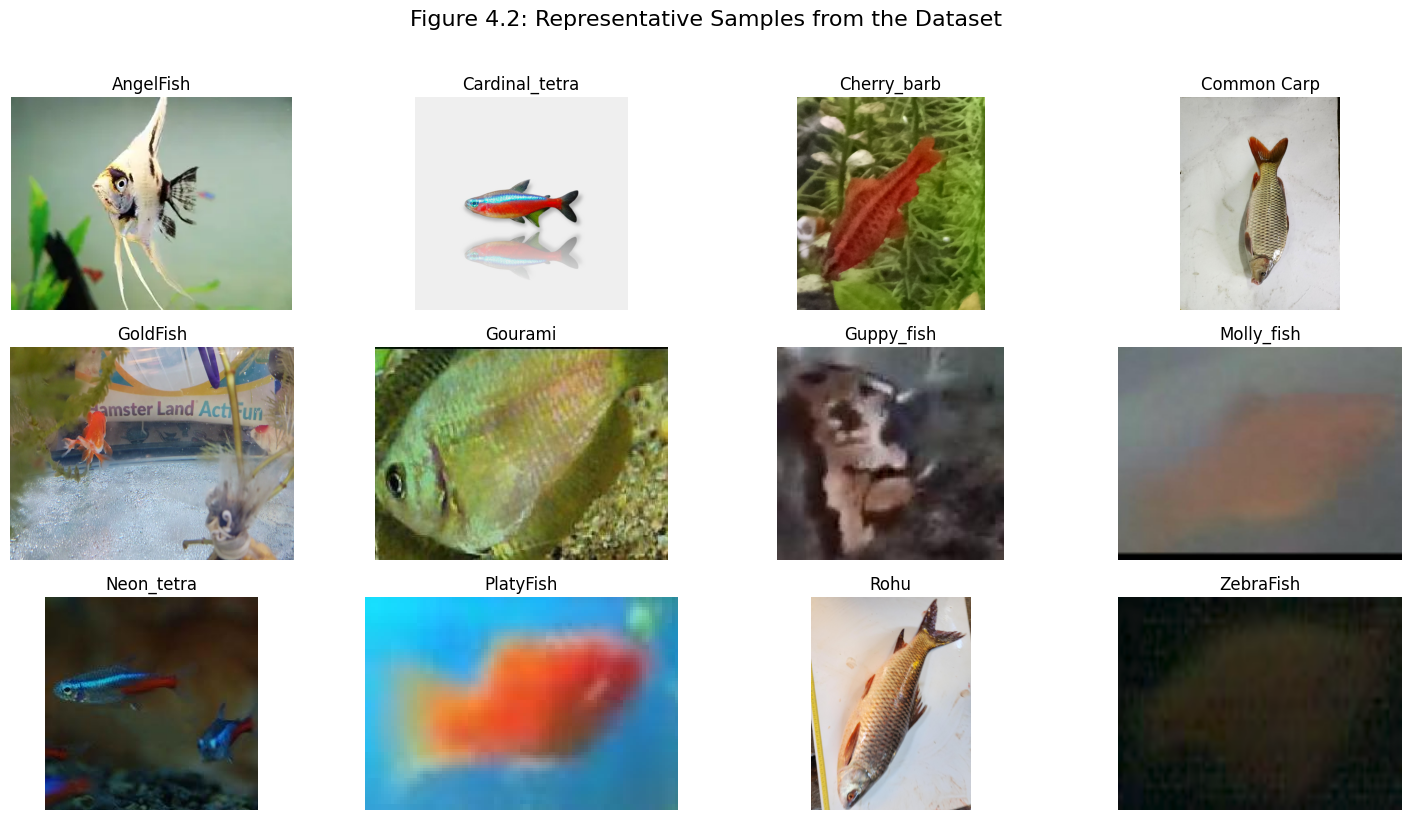

In [ ]:
import matplotlib.pyplot as plt
import os
import random
import matplotlib.image as mpimg

# Define your dataset path
dataset_path = '/content/drive/MyDrive/FYP Project/dataset_5/train'  # <--- CHANGE THIS TO YOUR ACTUAL PATH

# Get all class names (folder names)
class_names = sorted(os.listdir(dataset_path))

# Create a figure
plt.figure(figsize=(15, 8))
plt.suptitle("Figure 4.2: Representative Samples from the Dataset", fontsize=16, y=1.02)

# Loop through classes and plot one image from each
for i, class_name in enumerate(class_names):
    class_folder = os.path.join(dataset_path, class_name)

    # Check if it's actually a folder
    if os.path.isdir(class_folder):
        # Pick a random image
        images = os.listdir(class_folder)
        if len(images) > 0:
            random_image = random.choice(images)
            img_path = os.path.join(class_folder, random_image)

            # Load and display
            img = mpimg.imread(img_path)

            # Create subplot (3 rows, 4 columns for 11 classes)
            plt.subplot(3, 4, i + 1)
            plt.imshow(img)
            plt.title(class_name)
            plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# resnet training = resnet_4
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from google.colab import drive
import os
import zipfile

# ==========================================
# 1. SETUP & UNZIP (High Speed)
# ==========================================
drive.mount('/content/drive')

# PATH CONFIGURATION
ZIP_PATH = '/content/drive/MyDrive/FYP Project/dataset_4.zip' # <--- Make sure this matches your file!
EXTRACT_PATH = '/content/drive/MyDrive/FYP Project/dataset_4'          # Extract to Colab local disk (Fast)

if not os.path.exists(EXTRACT_PATH):
    print("🚀 Unzipping dataset... (This makes training 10x faster)")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)
    print("✅ Extraction complete!")
else:
    print("Dataset already extracted.")

# Define directory paths inside the unzipped folder
# Adjust 'final_dataset_split' if your zip structure is different
TRAIN_DIR = os.path.join(EXTRACT_PATH, 'train')
VAL_DIR = os.path.join(EXTRACT_PATH, 'val')

# ==========================================
# 2. DATA GENERATORS
# ==========================================
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

print("Setting up data generators...")

# Augmentation for Training
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input,
    horizontal_flip=True,      # Safe to keep (flipping a flipped fish is still valid)
    width_shift_range=0.1,     # Very slight movement is okay
    height_shift_range=0.1     # Very slight movement is okay
)

# No augmentation for Validation
val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical'
)

# Detect number of classes automatically
NUM_CLASSES = len(train_generator.class_indices)
print(f"✅ Detected {NUM_CLASSES} classes (Should be 11 now including Neon Tetra)")

# ==========================================
# 3. BUILD NEW MODEL (ResNet V3)
# ==========================================
print("Building Fresh ResNet50 Model...")

# Load Base (ImageNet weights, no top)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Create new "Head" for your 22 classes
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x) # Helps prevent overfitting
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# FREEZE the base first (Standard Transfer Learning rule)
# We only train the new head for the first few epochs
for layer in base_model.layers:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# ==========================================
# 4. PHASE 1: WARM UP (Train Head Only)
# ==========================================
print("\n--- PHASE 1: WARM UP (Training new layers only) ---")
# This is quick, just to get the new 'Neon Tetra' neuron ready
history_warmup = model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator
)

# ==========================================
# 5. PHASE 2: FINE TUNING (The Real Training)
# ==========================================
print("\n--- PHASE 2: FINE TUNING (Unfreezing base) ---")

# Unfreeze the top layers of ResNet to learn specific features (scales/stripes)
base_model.trainable = True

# Fine-tune from layer 140 onwards (Stage 5)
FINE_TUNE_AT = 140
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

# Recompile with LOW learning rate (Crucial!)
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Callbacks to save the best version
checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/FYP Project/resnet50_4.keras', # New Name!
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

# Train longer this time
history_fine = model.fit(
    train_generator,
    epochs=20, # Give it time to learn the Neon vs Cardinal difference
    validation_data=val_generator,
    callbacks=[checkpoint, early_stop]
)

print("Training Complete! Best model saved as 'resnet50_4.keras'")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 Unzipping dataset... (This makes training 10x faster)
✅ Extraction complete!
Setting up data generators...
Found 18198 images belonging to 11 classes.
Found 1364 images belonging to 11 classes.
✅ Detected 11 classes (Should be 11 now including Neon Tetra)
Building Fresh ResNet50 Model...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step

--- PHASE 1: WARM UP (Training new layers only) ---


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
569/569 ━━━━━━━━━━━━━━━━━━━━ 405s 681ms/step - accuracy: 0.7493 - loss: 0.7573 - val_accuracy: 0.9677 - val_loss: 0.0970
Epoch 2/5
569/569 ━━━━━━━━━━━━━━━━━━━━ 363s 638ms/step - accuracy: 0.9441 - loss: 0.1590 - val_accuracy: 0.9780 - val_loss: 0.0659
Epoch 3/5
569/569 ━━━━━━━━━━━━━━━━━━━━ 363s 637ms/step - accuracy: 0.9548 - loss: 0.1245 - val_accuracy: 0.9817 - val_loss: 0.0579
Epoch 4/5
569/569 ━━━━━━━━━━━━━━━━━━━━ 364s 640ms/step - accuracy: 0.9611 - loss: 0.1067 - val_accuracy: 0.9868 - val_loss: 0.0505
Epoch 5/5
569/569 ━━━━━━━━━━━━━━━━━━━━ 382s 639ms/step - accuracy: 0.9664 - loss: 0.0978 - val_accuracy: 0.9853 - val_loss: 0.0502

--- PHASE 2: FINE TUNING (Unfreezing base) ---
Epoch 1/20
569/569 ━━━━━━━━━━━━━━━━━━━━ 0s 619ms/step - accuracy: 0.9712 - loss: 0.0816
Epoch 1: val_accuracy improved from -inf to 0.98534, saving model to /content/drive/MyDrive/FYP Project/resnet50_4.keras
569/569 ━━━━━━━━━━━━━━━━━━━━ 381s 651ms/step - accuracy: 0.9712 - loss: 0.0816 - val_acc

In [ ]:
# resnet training = resnet_5
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from google.colab import drive
import os
import zipfile

# ==========================================
# 1. SETUP & UNZIP (High Speed)
# ==========================================
drive.mount('/content/drive')

# PATH CONFIGURATION
ZIP_PATH = '/content/drive/MyDrive/FYP Project/dataset_5.zip' # <--- Make sure this matches your file!
EXTRACT_PATH = '/content/dataset_5'          # Extract to Colab local disk (Fast)

if not os.path.exists(EXTRACT_PATH):
    print("🚀 Unzipping dataset... (This makes training 10x faster)")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)
    print("✅ Extraction complete!")
else:
    print("Dataset already extracted.")

# Define directory paths inside the unzipped folder
# Adjust 'final_dataset_split' if your zip structure is different
TRAIN_DIR = os.path.join(EXTRACT_PATH, 'train')
VAL_DIR = os.path.join(EXTRACT_PATH, 'val')

# ==========================================
# 2. DATA GENERATORS
# ==========================================
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

print("Setting up data generators...")

# Augmentation for Training
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input,
    horizontal_flip=True,      # Safe to keep (flipping a flipped fish is still valid)
    width_shift_range=0.1,     # Very slight movement is okay
    height_shift_range=0.1     # Very slight movement is okay
)

# No augmentation for Validation
val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical'
)

# Detect number of classes automatically
NUM_CLASSES = len(train_generator.class_indices)
print(f"✅ Detected {NUM_CLASSES} classes (Should be 12 now including Neon Tetra)")

# ==========================================
# 3. BUILD NEW MODEL (ResNet V3)
# ==========================================
print("Building Fresh ResNet50 Model...")

# Load Base (ImageNet weights, no top)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Create new "Head" for your 22 classes
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x) # Helps prevent overfitting
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# FREEZE the base first (Standard Transfer Learning rule)
# We only train the new head for the first few epochs
for layer in base_model.layers:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# ==========================================
# 4. PHASE 1: WARM UP (Train Head Only)
# ==========================================
print("\n--- PHASE 1: WARM UP (Training new layers only) ---")
# This is quick, just to get the new 'Neon Tetra' neuron ready
history_warmup = model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator
)

# ==========================================
# 5. PHASE 2: FINE TUNING (The Real Training)
# ==========================================
print("\n--- PHASE 2: FINE TUNING (Unfreezing base) ---")

# Unfreeze the top layers of ResNet to learn specific features (scales/stripes)
base_model.trainable = True

# Fine-tune from layer 140 onwards (Stage 5)
FINE_TUNE_AT = 140
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

# Recompile with LOW learning rate (Crucial!)
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Callbacks to save the best version
checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/FYP Project/resnet50_5.keras', # New Name!
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

# Train longer this time
history_fine = model.fit(
    train_generator,
    epochs=20, # Give it time to learn the Neon vs Cardinal difference
    validation_data=val_generator,
    callbacks=[checkpoint, early_stop]
)

print("Training Complete! Best model saved as 'resnet50_5.keras'")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 Unzipping dataset... (This makes training 10x faster)
✅ Extraction complete!
Setting up data generators...
Found 20285 images belonging to 12 classes.
Found 1688 images belonging to 12 classes.
✅ Detected 12 classes (Should be 12 now including Neon Tetra)
Building Fresh ResNet50 Model...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step

--- PHASE 1: WARM UP (Training new layers only) ---
Epoch 1/5
634/634 ━━━━━━━━━━━━━━━━━━━━ 390s 591ms/step - accuracy: 0.8723 - loss: 0.3807 - val_accuracy: 0.9686 - val_loss: 0.0967
Epoch 2/5
634/634 ━━━━━━━━━━━━━━━━━━━━ 347s 547ms/step - accuracy: 0.9552 - loss: 0.1320 - val_accuracy: 0.9757 - val_loss: 0.0679
Epoch 3/5
634/634 ━━━━━━━━━━━━━━━━━━━━ 347s 547ms/step - accuracy: 0.9652 - loss: 0.1007 - val_accuracy: 0.9787 - val_loss: 0.0653
Epoch 4/5
634/634 ━━━━━━━━━━━━━━━━━━━━ 349s 549ms/step - accuracy: 0.9681 - loss: 0

In [ ]:
!unzip "/content/drive/MyDrive/FYP Project/dataset_5.zip" -d "/content/drive/MyDrive/FYP Project"

Streaming output truncated to the last 5000 lines.
  inflating: /content/drive/MyDrive/FYP Project/train/Rohu/Rohu (49).jpg  
  inflating: /content/drive/MyDrive/FYP Project/train/Rohu/Rohu (490).jpg  
  inflating: /content/drive/MyDrive/FYP Project/train/Rohu/Rohu (491).jpg  
  inflating: /content/drive/MyDrive/FYP Project/train/Rohu/Rohu (492).jpg  
  inflating: /content/drive/MyDrive/FYP Project/train/Rohu/Rohu (493).jpg  
  inflating: /content/drive/MyDrive/FYP Project/train/Rohu/Rohu (494).jpg  
  inflating: /content/drive/MyDrive/FYP Project/train/Rohu/Rohu (495).jpg  
  inflating: /content/drive/MyDrive/FYP Project/train/Rohu/Rohu (496).jpg  
  inflating: /content/drive/MyDrive/FYP Project/train/Rohu/Rohu (497).jpg  
  inflating: /content/drive/MyDrive/FYP Project/train/Rohu/Rohu (498).jpg  
  inflating: /content/drive/MyDrive/FYP Project/train/Rohu/Rohu (499).jpg  
  inflating: /content/drive/MyDrive/FYP Project/train/Rohu/Rohu (5).jpg  
  inflating: /content/drive/MyDrive/FYP 

Loading model from Drive...
Setting up test data generator...
Found 1689 images belonging to 12 classes.

Generating predictions for the test set...
53/53 ━━━━━━━━━━━━━━━━━━━━ 385s 7s/step

--- Plotting Confusion Matrix ---


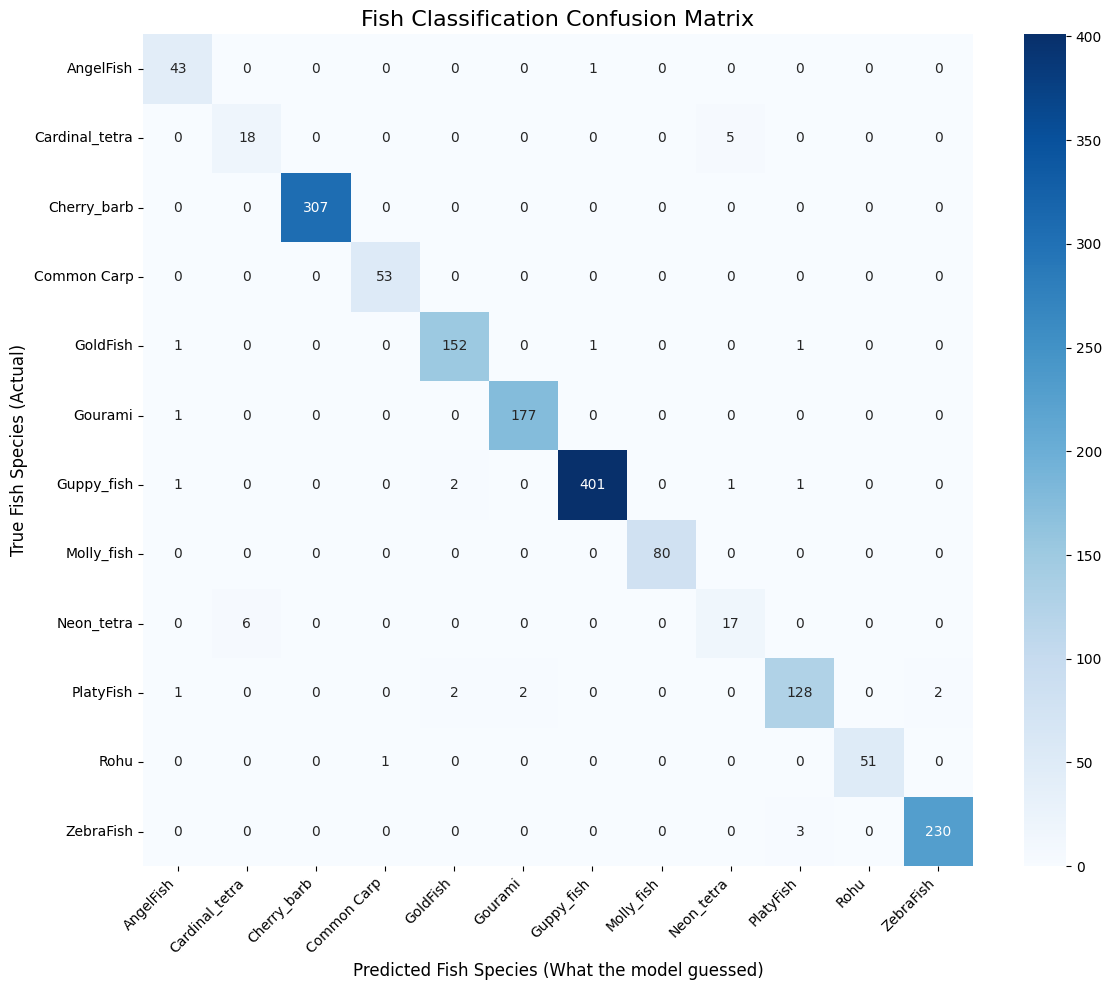


--- Detailed Classification Report ---
                precision    recall  f1-score   support

     AngelFish       0.91      0.98      0.95        44
Cardinal_tetra       0.75      0.78      0.77        23
   Cherry_barb       1.00      1.00      1.00       307
   Common Carp       0.98      1.00      0.99        53
      GoldFish       0.97      0.98      0.98       155
       Gourami       0.99      0.99      0.99       178
    Guppy_fish       1.00      0.99      0.99       406
    Molly_fish       1.00      1.00      1.00        80
    Neon_tetra       0.74      0.74      0.74        23
     PlatyFish       0.96      0.95      0.96       135
          Rohu       1.00      0.98      0.99        52
     ZebraFish       0.99      0.99      0.99       233

      accuracy                           0.98      1689
     macro avg       0.94      0.95      0.94      1689
  weighted avg       0.98      0.98      0.98      1689



In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os

# ==========================================
# 1. SETUP PATHS
# ==========================================
TEST_DIR = '/content/drive/MyDrive/FYP Project/dataset_5/test' # Reminder: Make sure your data is unzipped here!
MODEL_PATH = '/content/drive/MyDrive/FYP Project/resnet50_5.keras'

# ==========================================
# 2. LOAD MODEL & GENERATOR (Fixes the errors!)
# ==========================================
print("Loading model from Drive...")
model = tf.keras.models.load_model(MODEL_PATH)

print("Setting up test data generator...")
test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False # CRITICAL: Must be False for confusion matrix
)

# ==========================================
# 3. GET PREDICTIONS
# ==========================================
print("\nGenerating predictions for the test set...")
predictions = model.predict(test_generator, verbose=1)

y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# ==========================================
# 4. PLOT CONFUSION MATRIX
# ==========================================
print("\n--- Plotting Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('Fish Classification Confusion Matrix', fontsize=16)
plt.ylabel('True Fish Species (Actual)', fontsize=12)
plt.xlabel('Predicted Fish Species (What the model guessed)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ==========================================
# 5. PRINT REPORT
# ==========================================
print("\n--- Detailed Classification Report ---")
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
from tensorflow.keras.preprocessing.image import load_img

def plot_misclassified_images(model, test_generator, class_names):
    # Get all predictions for the test set
    filenames = test_generator.filenames
    y_true = test_generator.classes
    predictions = model.predict(test_generator)
    y_pred = np.argmax(predictions, axis=1)

    # Find indices where Cardinal Tetra (index 1) was missed
    # Check your class_indices to confirm Cardinal Tetra is index 1
    target_class_idx = test_generator.class_indices['Cardinal_tetra']
    errors = np.where((y_true == target_class_idx) & (y_pred != target_class_idx))[0]

    if len(errors) == 0:
        print("No errors found for Cardinal Tetra!")
        return

    # Plot the first few errors
    plt.figure(figsize=(15, 10))
    for i, idx in enumerate(errors[:6]):
        plt.subplot(2, 3, i + 1)
        img_path = os.path.join(test_generator.directory, filenames[idx])
        img = load_img(img_path, target_size=(224, 224))
        plt.imshow(img)

        pred_label = class_names[y_pred[idx]]
        true_label = class_names[y_true[idx]]

        plt.title(f"True: {true_label}\nPred: {pred_label}", color='red')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Example usage (run this after your model evaluation)
# plot_misclassified_images(model, test_generator, list(test_generator.class_indices.keys()))

In [ ]:
# resnet training = resnet_5
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from google.colab import drive
import os
import zipfile

# ==========================================
# 1. SETUP & UNZIP (High Speed)
# ==========================================
drive.mount('/content/drive')

# PATH CONFIGURATION
ZIP_PATH = '/content/drive/MyDrive/FYP Project/dataset_5.zip' # <--- Make sure this matches your file!
EXTRACT_PATH = '/content/drive/MyDrive/FYP Project'          # Extract to Colab local disk (Fast)

if not os.path.exists(EXTRACT_PATH):
    print("🚀 Unzipping dataset... (This makes training 10x faster)")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)
    print("✅ Extraction complete!")
else:
    print("Dataset already extracted.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset already extracted.


In [ ]:
from tensorflow import keras

# Load your existing model
model = keras.models.load_model("/content/drive/MyDrive/FYP Project/resnet50_5.keras")

# Save as .h5
model.save("/content/drive/MyDrive/FYP Project/resnet50_5_fixed.h5")

print("✅ Converted to .h5 successfully!")

✅ Converted to .h5 successfully!
